# Assignment 1 – Machine Learning Foundations
Karim Masoud
UCI Bank Marketing Dataset
February 2026
GitHub Repository: https://github.com/ksamaanieu2024/ML-fundamentals-2026 aa


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import RandomOverSampler

## 1. Identifying the Prediction Target


In [2]:

df = pd.read_csv("bank-additional.csv", sep=";")

df.shape

(4119, 21)

In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [5]:
df['y'].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

The target variable for this assignment is y, which indicates whether a client subscribed to a term deposit during the marketing campaign.

This variable represents the core business objective of the campaign: predicting client subscription based on information available at the time of contact.

Although other variables such as duration or poutcome may appear predictive, they should not be treated as targets because:

duration measures call duration, which is only known after the call ends and therefore is not available at prediction time.

poutcome describes the outcome of a previous campaign, not the current subscription decision.

Therefore, y is the correct prediction objective.

## 2. Data Loading and Exploration

In this section, we inspect the structure of the dataset, identify numerical and categorical variables, analyze the distribution of the target variable, and detect potential missing values or problematic features.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4119.0,40.113620,10.313362,18.000,32.000,38.000,47.000,88.000
duration,4119.0,256.788055,254.703736,0.000,103.000,181.000,317.000,3643.000
campaign,4119.0,2.537266,2.568159,1.000,1.000,2.000,3.000,35.000
pdays,4119.0,960.422190,191.922786,0.000,999.000,999.000,999.000,999.000
previous,4119.0,0.190337,0.541788,0.000,0.000,0.000,0.000,6.000
emp.var.rate,4119.0,0.084972,1.563114,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,4119.0,93.579704,0.579349,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,4119.0,-40.499102,4.594578,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,4119.0,3.621356,1.733591,0.635,1.334,4.857,4.961,5.045
nr.employed,4119.0,5166.481695,73.667904,4963.600,5099.100,5191.000,5228.100,5228.100


In [8]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'str']).columns

print("Numerical variables:")
print(numerical_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')

Categorical variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')


The  dataset contains 4119 observations and 21 variables.

There are:

10 numerical variables (int64 and float64)

11 categorical variables (object type)

No explicit missing values (NaN) are present. However, the absence of NaN does not imply the absence of missing information. Some categorical variables may contain implicit missing values encoded as special categories, which must be investigated.

In [9]:
for col in categorical_cols:
    print(f"{col}:")
    print(df[col].value_counts())
    print("-" * 40)

job:
job
admin.           1012
blue-collar       884
technician        691
services          393
management        324
retired           166
self-employed     159
entrepreneur      148
unemployed        111
housemaid         110
student            82
unknown            39
Name: count, dtype: int64
----------------------------------------
marital:
marital
married     2509
single      1153
divorced     446
unknown       11
Name: count, dtype: int64
----------------------------------------
education:
education
university.degree      1264
high.school             921
basic.9y                574
professional.course     535
basic.4y                429
basic.6y                228
unknown                 167
illiterate                1
Name: count, dtype: int64
----------------------------------------
default:
default
no         3315
unknown     803
yes           1
Name: count, dtype: int64
----------------------------------------
housing:
housing
yes        2175
no         1839
unknown     105

In [10]:
for col in categorical_cols:
    if "unknown" in df[col].values:
        unknown_count = (df[col] == "unknown").sum()
        percentage = unknown_count / len(df) * 100
        print(f"{col}: {unknown_count} unknown values ({percentage:.2f}%)")

job: 39 unknown values (0.95%)
marital: 11 unknown values (0.27%)
education: 167 unknown values (4.05%)
default: 803 unknown values (19.50%)
housing: 105 unknown values (2.55%)
loan: 105 unknown values (2.55%)


The variable duration requires special consideration. It measures the duration of the phone call and is only known after the interaction with the client has concluded. Since the objective is to predict subscription at the time of contact, duration would not be available at prediction time and therefore introduces data leakage.

For this reason, duration must be removed before modeling.

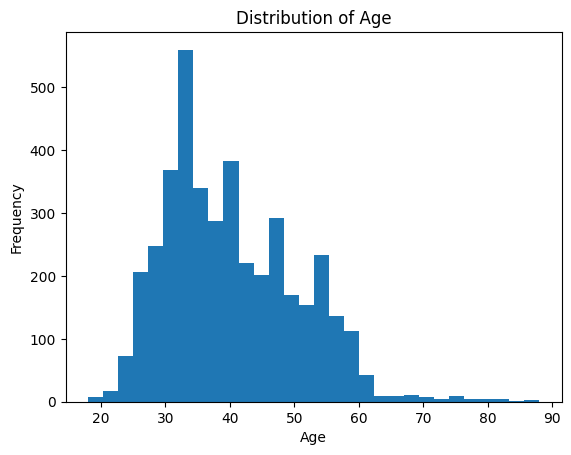

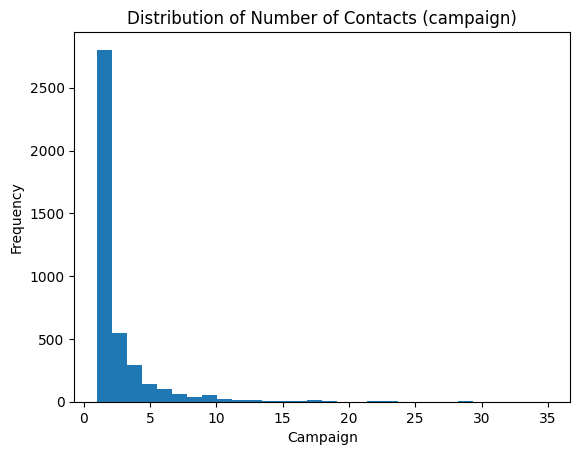

In [11]:
plt.figure()
plt.hist(df["age"], bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df["campaign"], bins=30)
plt.title("Distribution of Number of Contacts (campaign)")
plt.xlabel("Campaign")
plt.ylabel("Frequency")
plt.show()

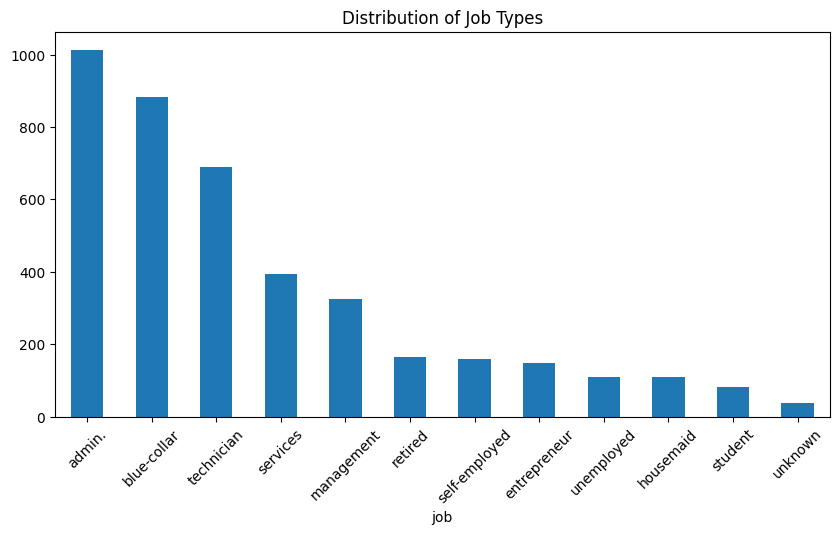

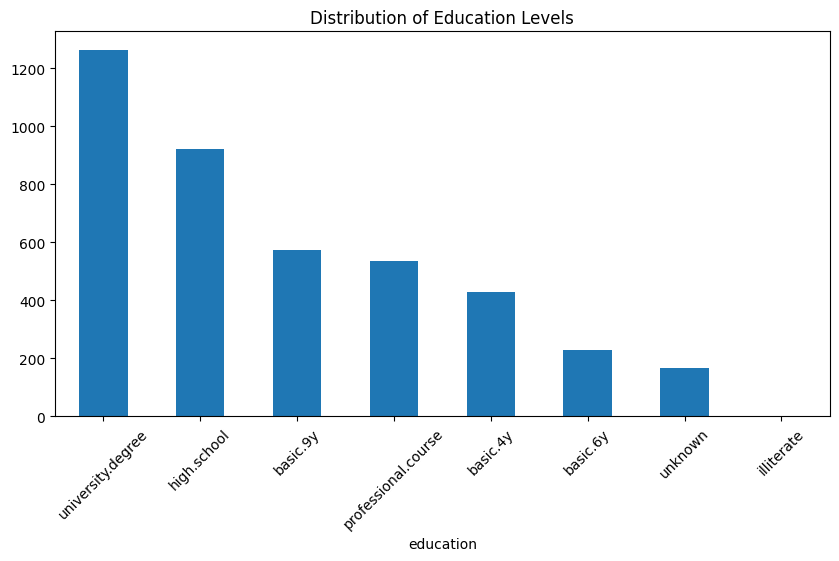

In [12]:
plt.figure(figsize=(10,5))
df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of Job Types")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
df["education"].value_counts().plot(kind="bar")
plt.title("Distribution of Education Levels")
plt.xticks(rotation=45)
plt.show()

## 3. Data Splitting

In [13]:
X = df.drop(columns=["y"])
y = df["y"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Training set size: (2883, 20)
Validation set size: (618, 20)
Test set size: (618, 20)


In [14]:
def show_distribution(name, target):
    print(f"{name} distribution:")
    print(target.value_counts(normalize=True))
    print("-" * 40)

show_distribution("Train", y_train)
show_distribution("Validation", y_val)
show_distribution("Test", y_test)

Train distribution:
y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64
----------------------------------------
Validation distribution:
y
no     0.889968
yes    0.110032
Name: proportion, dtype: float64
----------------------------------------
Test distribution:
y
no     0.891586
yes    0.108414
Name: proportion, dtype: float64
----------------------------------------


The dataset was split into training (70%), validation (15%), and test (15%) sets using stratified sampling with respect to the target variable y.

Stratification is necessary because the dataset is imbalanced (~89% “no”, ~11% “yes”). Without stratification, some splits could contain disproportionate class distributions, leading to unreliable evaluation metrics.

The split was performed before any preprocessing steps (such as encoding, scaling, resampling, or feature selection) to prevent data leakage. Any transformation that learns parameters from data must be fitted using the training set only.

In [15]:
X_train = X_train.drop(columns=["duration"])
X_val = X_val.drop(columns=["duration"])
X_test = X_test.drop(columns=["duration"])

print("Updated training shape:", X_train.shape)

Updated training shape: (2883, 19)


In [16]:
categorical_cols = X_train.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if "unknown" in X_train[col].values:
        unknown_count = (X_train[col] == "unknown").sum()
        percentage = unknown_count / len(X_train) * 100
        print(f"{col}: {unknown_count} unknown values ({percentage:.2f}%)")

job: 25 unknown values (0.87%)
marital: 7 unknown values (0.24%)
education: 112 unknown values (3.88%)
default: 577 unknown values (20.01%)
housing: 65 unknown values (2.25%)
loan: 65 unknown values (2.25%)


/var/folders/13/skly95sd5glc149_m876wpt40000gn/T/ipykernel_5282/1463584743.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns


## 4. Managing Missing Values

Explicit vs implicit missingness

The dataset contains no explicit missing values according to df.info(). Several categorical variables contain implicit missing values encoded as the category "unknown".

Handling strategy

For categorical variables with "unknown":

We will treat "unknown" as a valid separate category rather than imputing or dropping rows.

Justification: "unknown" can carry information (missingness may correlate with subscription behavior) and dropping would unnecessarily reduce data and potentially bias results.

Since "unknown" is already an explicit category string, no additional imputation is required at this stage. The handling will be implemented naturally during categorical encoding.

All transformations will be fitted on the training set only to avoid data leakage.

In [17]:
# Re-identify columns after removing duration
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

print("Numerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)

Numerical columns: Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')

Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')


/var/folders/13/skly95sd5glc149_m876wpt40000gn/T/ipykernel_5282/2538636901.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns


## 5. Encoding Categorical Variables

### Nominal vs ordinal variables — classification and encoding justification

**Categorical variables (training set):** `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`.

**Ordinal vs nominal classification**
- - Ordinal:
  - `education` — has a natural ordering.
    *Comment:* `education` could be encoded ordinally if we were confident the spacing between levels is meaningful and linear. However, the categories include heterogeneous labels and a small rare category (`illiterate`), so treating it as strictly ordinal risks imposing an unjustified numeric ordering.
- - Nominal :
  - `job`, `marital`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome`.

**Chosen encoding strategy**
- - One-Hot Encoding for all categorical variables.
  - **Why:** One-Hot Encoding avoids imposing artificial order on nominal variables and prevents the model from assuming a linear relationship between encoded values and log-odds. For `education`, although an ordinal interpretation exists, the categorical labels and uneven spacing make One-Hot safer and more interpretable for a linear model.
  - **Implementation details:** use `OneHotEncoder(handle_unknown="ignore")` and fit the encoder on the training set only. Then apply the fitted encoder to validation and test sets. This prevents leakage from future data.
  - **Effect on dimensionality and interpretability:** One-Hot Encoding increases dimensionality . This lets Logistic Regression assign an independent coefficient to each category, improving interpretability . The increased dimensionality is visible in the preprocessing output .
  - **Effect on decision boundaries:** For a linear model, One-Hot Encoding allows piecewise constant contributions per category, while preserving linearity in numeric features. It does not enable complex nonlinear interactions by itself — those would require feature crossing or nonlinear models.
  - **Robustness:** `handle_unknown="ignore"` ensures unseen categories in validation/test do not break the pipeline. Any encoding parameters (e.g., categories list) are learned from the training set only.

All categorical variables were encoded using One-Hot Encoding.

Justification:

Logistic Regression assumes linear relationships between features and the log-odds of the target.

Nominal categorical variables (e.g., job, marital status) have no intrinsic ordering; therefore, One-Hot Encoding prevents introducing artificial ordinal structure.

The encoder was fitted on the training set only to prevent data leakage.

The dimensionality increased from 19 to 62 features, which allows the linear model to assign separate coefficients to each category.

One-Hot Encoding enables the model to learn different log-odds contributions for each category without assuming numerical ordering.

The parameter handle_unknown="ignore" ensures robustness when unseen categories appear in validation or test sets.

## 6. Feature Scaling

Numerical features were standardized using StandardScaler, which transforms each feature to have zero mean and unit variance.

Justification:

Logistic Regression is optimized using gradient-based methods. When features are on different scales (e.g., age vs nr.employed), optimization may converge slowly or assign disproportionate importance to large-scale variables.

Standardization ensures that all numerical features contribute comparably during optimization.

Scaling makes regularization penalties (L1/L2) comparable across coefficients.

The scaler was fitted on the training set only to prevent information leakage.

Categorical features were not scaled because One-Hot Encoding produces binary indicators (0/1), which do not require scaling.

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed val shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (2883, 62)
Processed val shape: (618, 62)
Processed test shape: (618, 62)


## 7. Feature Selection

Low-Variance Feature Removal

After encoding and scaling, feature variance was computed using the training set only.

Five features exhibited extremely low variance (< 0.01), corresponding to very rare categories . Such features contribute minimal information to a linear model and may increase instability of coefficient estimation.

These features were removed from the training, validation, and test sets using indices determined exclusively from the training data to prevent data leakage.

Low-variance removal improves numerical stability and reduces unnecessary model complexity without sacrificing meaningful predictive signal.

In [19]:

train_numeric = X_train[numerical_cols]

correlation_matrix = train_numeric.corr()

correlation_matrix

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.013724,-0.047688,0.040628,-0.017167,0.002207,0.114373,-0.007678,-0.036400
campaign,-0.013724,1.000000,0.068110,-0.098123,0.187127,0.149502,0.013836,0.169898,0.169503
pdays,-0.047688,0.068110,1.000000,-0.607106,0.282890,0.060471,-0.111135,0.316205,0.402703
previous,0.040628,-0.098123,-0.607106,1.000000,-0.422470,-0.173426,-0.030424,-0.466142,-0.519873
emp.var.rate,-0.017167,0.187127,0.282890,-0.422470,1.000000,0.756447,0.171337,0.969648,0.895815
cons.price.idx,0.002207,0.149502,0.060471,-0.173426,0.756447,1.000000,0.025311,0.654637,0.469817
cons.conf.idx,0.114373,0.013836,-0.111135,-0.030424,0.171337,0.025311,1.000000,0.256168,0.087675
euribor3m,-0.007678,0.169898,0.316205,-0.466142,0.969648,0.654637,0.256168,1.000000,0.942087
nr.employed,-0.036400,0.169503,0.402703,-0.519873,0.895815,0.469817,0.087675,0.942087,1.000000


In [20]:
X_train = X_train.drop(columns=["emp.var.rate"])
X_val = X_val.drop(columns=["emp.var.rate"])
X_test = X_test.drop(columns=["emp.var.rate"])

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("New processed shape:", X_train_processed.shape)

New processed shape: (2883, 61)


/var/folders/13/skly95sd5glc149_m876wpt40000gn/T/ipykernel_5282/2687017435.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns


In [21]:

X_train_array = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
variances = np.var(X_train_array, axis=0)

low_variance_features = np.where(variances < 0.01)[0]
print("Number of low variance features (after removing emp.var.rate):", len(low_variance_features))

feature_names = preprocessor.get_feature_names_out()
low_var_feature_names = feature_names[low_variance_features]

print("\nLow variance features:")
for f in low_var_feature_names:
    print(f)

Number of low variance features (after removing emp.var.rate): 5

Low variance features:
cat__job_unknown
cat__marital_unknown
cat__education_illiterate
cat__default_yes
cat__month_dec


In [22]:
X_train_final = np.delete(X_train_array, low_variance_features, axis=1)

X_val_array = X_val_processed.toarray() if hasattr(X_val_processed, "toarray") else X_val_processed
X_test_array = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

X_val_final = np.delete(X_val_array, low_variance_features, axis=1)
X_test_final = np.delete(X_test_array, low_variance_features, axis=1)

print("Final train shape:", X_train_final.shape)
print("Final val shape:", X_val_final.shape)
print("Final test shape:", X_test_final.shape)

Final train shape: (2883, 56)
Final val shape: (618, 56)
Final test shape: (618, 56)


**Multicollinearity Analysis**

Correlation analysis was performed on numerical variables using the training set only.

Very high correlations (> 0.90) were observed among macroeconomic variables, particularly:

emp.var.rate and euribor3m (≈ 0.97)

euribor3m and nr.employed (≈ 0.94)

Such high correlations indicate multicollinearity, which can destabilize Logistic Regression coefficient estimates and reduce interpretability.

To reduce redundancy and improve coefficient stability, emp.var.rate was removed from the dataset.

All feature selection decisions were made using the training set only to prevent data leakage.

**Threshold Justification**

Low-variance threshold:
Features with variance lower than 0.01 (computed on the training set after scaling and encoding) were considered low-variance and removed.

For one-hot encoded variables, variance depends on the category frequency (p × (1 − p)). A variance below 0.01 corresponds to extremely rare categories, which contribute minimal information and may destabilize coefficient estimation in Logistic Regression.

Correlation threshold:
Numerical features with absolute correlation greater than 0.90 were considered highly collinear.

A threshold of 0.90 is commonly used to identify severe multicollinearity. Extremely correlated predictors inflate coefficient variance and reduce interpretability in linear models. Removing one variable from such pairs improves stability without substantial loss of information.

All thresholds were determined using the training set only to prevent data leakage.

## 8. Addressing Class Imbalance

Class Distribution (Training Set)

Class imbalance must be analyzed using the training set only, since resampling is part of the training procedure.

In [23]:
print("Training class distribution (counts):")
print(y_train.value_counts())

print("\nTraining class distribution (proportions):")
print(y_train.value_counts(normalize=True))

Training class distribution (counts):
y
no     2567
yes     316
Name: count, dtype: int64

Training class distribution (proportions):
y
no     0.890392
yes    0.109608
Name: proportion, dtype: float64


The training set shows a strong class imbalance:

Approximately 89% of observations correspond to "no".

Approximately 11% correspond to "yes".

This imbalance is substantial and may bias a Logistic Regression model toward predicting the majority class. A model that always predicts "no" would already achieve approximately 89% accuracy, which makes accuracy alone a misleading metric.

Therefore, resampling techniques will be considered to improve the model’s ability to detect the minority class.

In [24]:

ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(X_train_final, y_train)

print("Resampled training class distribution:")
print(pd.Series(y_train_resampled).value_counts())

Resampled training class distribution:
y
no     2567
yes    2567
Name: count, dtype: int64


Resampling Strategy

Random Oversampling was applied to the training set after preprocessing and feature selection.

Justification:

The dataset exhibits strong class imbalance (~89% majority class).

Random Oversampling replicates minority class samples to balance class frequencies.

This method does not assume a specific data distribution and is appropriate for a linear classifier such as Logistic Regression.

Resampling was applied after splitting and only to the training set to prevent information leakage.

If resampling were applied before splitting, synthetic or duplicated samples could appear in validation or test sets, artificially inflating performance and invalidating evaluation results.

Validation and test sets preserve the original class distribution to ensure realistic performance assessment.

## 9. Task Ordering and Pipeline Justification

**Task Ordering and Rationale**

The data preparation steps were carried out in a deliberate order to avoid methodological errors and data leakage.

First, the prediction target (y) was identified and justified. This clarified the objective of the analysis and ensured that all subsequent steps were aligned with the correct prediction task.

Next, exploratory data analysis was performed to understand the dataset structure, variable types, potential implicit missing values, and possible leakage sources (such as duration). This step helped identify features that should not be used in modeling.

The dataset was then split into training, validation, and test sets using stratified sampling. The split was performed before any preprocessing or transformation to ensure that information from validation or test data could not influence training.

After splitting, preprocessing steps were applied in the following sequence:

Removal of conceptually inappropriate features (duration).

Handling implicit missing values.

Encoding categorical variables using One-Hot Encoding.

Scaling numerical features using StandardScaler.

Performing feature selection (removal of highly correlated and low-variance features).

All transformations that required learning parameters (encoding, scaling, variance calculation, correlation analysis) were fitted exclusively on the training set and then applied to validation and test sets.

Class imbalance was addressed after preprocessing by applying Random Oversampling to the training set only. Validation and test sets retained the original class distribution to allow realistic performance evaluation.

Finally, the Logistic Regression model was trained on the processed and resampled training data and evaluated on the validation set.

**Why this order matters**

If preprocessing steps such as scaling, feature selection, or resampling were performed before splitting the dataset, information from validation or test data could leak into the training process. This would produce overly optimistic performance estimates and undermine the validity of the evaluation.

By splitting early and fitting all transformations only on the training data, the pipeline preserves the integrity of model assessment.


## 10. Logistic Regression Model and Evaluation

In [25]:

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_resampled, y_train_resampled)

print("Model trained successfully.")

Model trained successfully.


Validation Accuracy:  0.8382
Validation Precision: 0.3644
Validation Recall:    0.6324


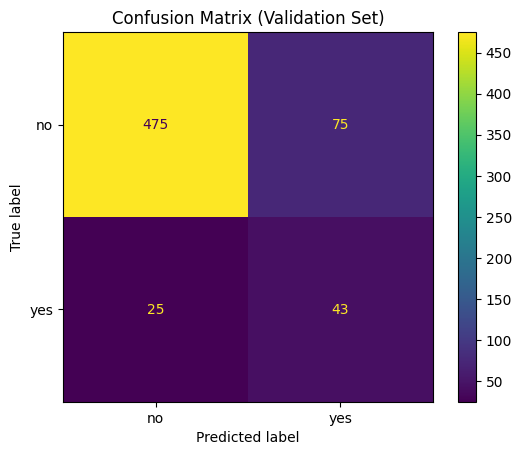

In [26]:
y_val_pred = model.predict(X_val_final)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes")
rec = recall_score(y_val, y_val_pred, pos_label="yes")

print(f"Validation Accuracy:  {acc:.4f}")
print(f"Validation Precision: {prec:.4f}")
print(f"Validation Recall:    {rec:.4f}")

cm = confusion_matrix(y_val, y_val_pred, labels=["no", "yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])

fig, ax = plt.subplots()
disp.plot(ax=ax, values_format="d")
ax.set_title("Confusion Matrix (Validation Set)")
plt.show()

In [27]:
majority_class = y_train.value_counts().idxmax()

y_val_zero = [majority_class] * len(y_val)

baseline_accuracy = accuracy_score(y_val, y_val_zero)

print(f"Zero Rule Baseline Accuracy: {baseline_accuracy:.4f}")

Zero Rule Baseline Accuracy: 0.8900


**Comparison with Zero Rule Baseline**

The Zero Rule baseline, which always predicts the majority class ("no"), achieves an accuracy of approximately 0.89 on the validation set. This is higher than the Logistic Regression model’s accuracy (0.838).

However, the baseline model has zero recall for the minority class ("yes"), meaning it fails completely to identify clients who subscribe to a term deposit.

In contrast, the Logistic Regression model achieves a recall of approximately 0.63 for the minority class. This demonstrates a substantial improvement in detecting positive cases, despite a reduction in overall accuracy.

This highlights the limitations of accuracy as a metric in imbalanced datasets and justifies the use of resampling and additional metrics such as precision and recall.